# Linear Regression on Kaggle's Car Dataset

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [112]:
# import dataset
df = pd.read_csv('../datasets/cardataset.csv')
df.sample(5)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
4715,Honda,Fit,2016,regular unleaded,130.0,4.0,AUTOMATIC,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,41,33,2202,16690
319,Nissan,370Z,2015,premium unleaded (required),332.0,6.0,AUTOMATIC,rear wheel drive,2.0,High-Performance,Compact,Coupe,26,19,2009,39270
4712,Honda,Fit,2015,regular unleaded,130.0,4.0,AUTOMATIC,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,38,32,2202,18360
2553,Honda,Civic,2015,premium unleaded (required),205.0,4.0,MANUAL,front wheel drive,2.0,"Factory Tuner,Performance",Compact,Coupe,31,22,2202,24390
6273,Suzuki,Kizashi,2011,regular unleaded,180.0,4.0,AUTOMATIC,all wheel drive,4.0,NaN,Midsize,Sedan,29,22,481,25499


## Exploratory Data Analysis

In [113]:
# number of rows in the dataset
len(df)

11914

In [114]:
# lowercase all column names, and replace space in column names with underscore
df.columns = df.columns.str.lower().str.replace(" ","_")

In [115]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [116]:
# Find columns with text values
string_columns = list(df.select_dtypes(include=['object']).columns)
for col in string_columns:
    df[col] = df[col].str.lower().str.replace(" ","_")

C:\Users\gupta\AppData\Local\Temp\ipykernel_2188\3511654387.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_columns = list(df.select_dtypes(include=['object']).columns)


In [117]:
df.head(5)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [118]:
df = df.dropna()

### Analyze Target Variable

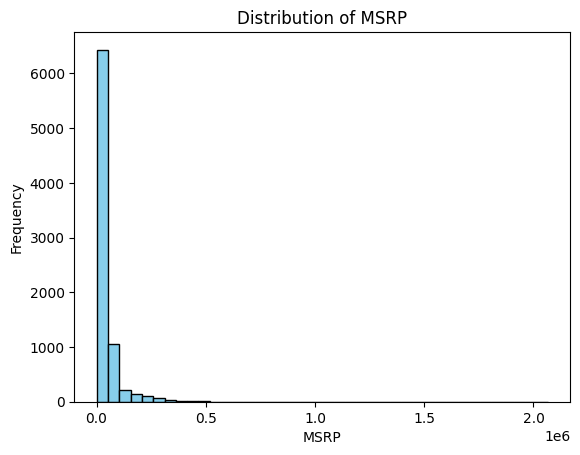

In [119]:
# Analyze target variable: MSRP
plt.hist(df['msrp'], bins=40, color='skyblue', edgecolor='black')
plt.xlabel('MSRP')
plt.ylabel('Frequency')
plt.title('Distribution of MSRP')
plt.show()

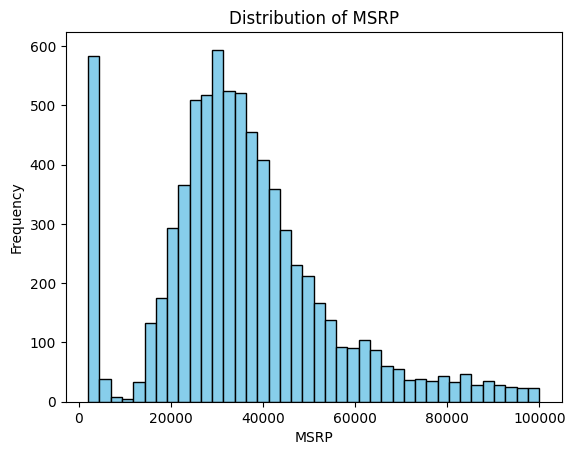

In [120]:
# lot of cars with low prices, and a very long tail
# lets view zoom-in
plt.hist(df.msrp[df.msrp < 100000], bins=40, color='skyblue', edgecolor='black')
plt.xlabel('MSRP')
plt.ylabel('Frequency')
plt.title('Distribution of MSRP')
plt.show()

### Address Missing Values

In [121]:
df.isnull().sum()

make                 0
model                0
year                 0
engine_fuel_type     0
engine_hp            0
engine_cylinders     0
transmission_type    0
driven_wheels        0
number_of_doors      0
market_category      0
vehicle_size         0
vehicle_style        0
highway_mpg          0
city_mpg             0
popularity           0
msrp                 0
dtype: int64

## Setup Validation Framework

In [122]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['msrp'])
y = df['msrp']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [123]:
# view shape of train and test datasets
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}, y_train: {y_train.shape}, y_test: {y_test.shape}')

X_train: (6467, 15), X_test: (1617, 15), y_train: (6467,), y_test: (1617,)


## One-Hot Encoding

In [124]:
# Initialize one-hot encoder
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [125]:
X_train_encoded_raw = encoder.fit_transform(X_train[string_columns])
X_test_encoded_raw = encoder.transform(X_test[string_columns])

In [126]:
# get new feature names
encoded_col_names = encoder.get_feature_names_out(string_columns)

In [127]:
X_train_encoded_df = pd.DataFrame(X_train_encoded_raw, columns=encoded_col_names, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded_raw, columns=encoded_col_names,index=X_test.index)

In [128]:
# rejoin and delete originals
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()
X_train_final = pd.concat([X_train[numeric_cols], X_train_encoded_df], axis=1)
X_test_final = pd.concat([X_test[numeric_cols], X_test_encoded_df], axis=1)

## Train Linear Regression Model

In [132]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train_final,y_train)
coef = regressor.coef_
intercept = regressor.intercept_

## Make Predictions

In [137]:
y_pred = regressor.predict(X_test_final)

## Evaluate the model

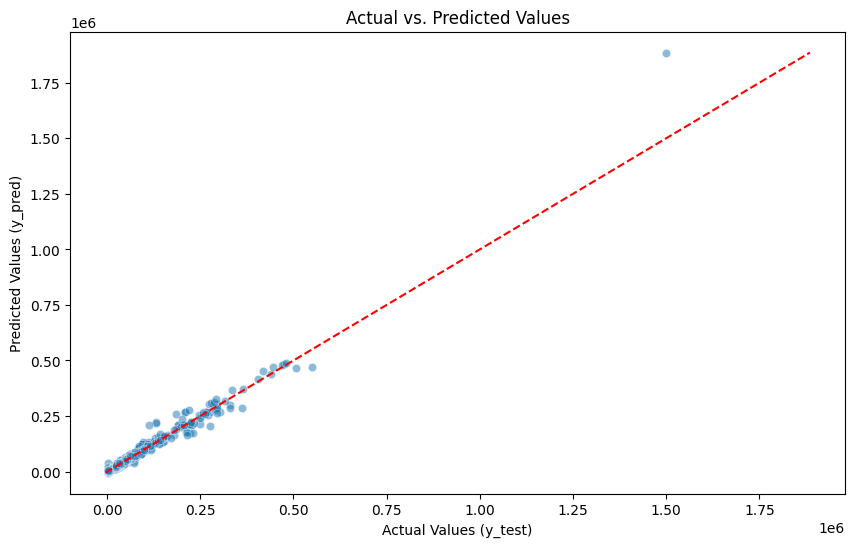

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create the plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)

# Add the "Perfect Prediction" line
# This represents where y_test == y_pred
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')
plt.title('Actual vs. Predicted Values')
plt.show()

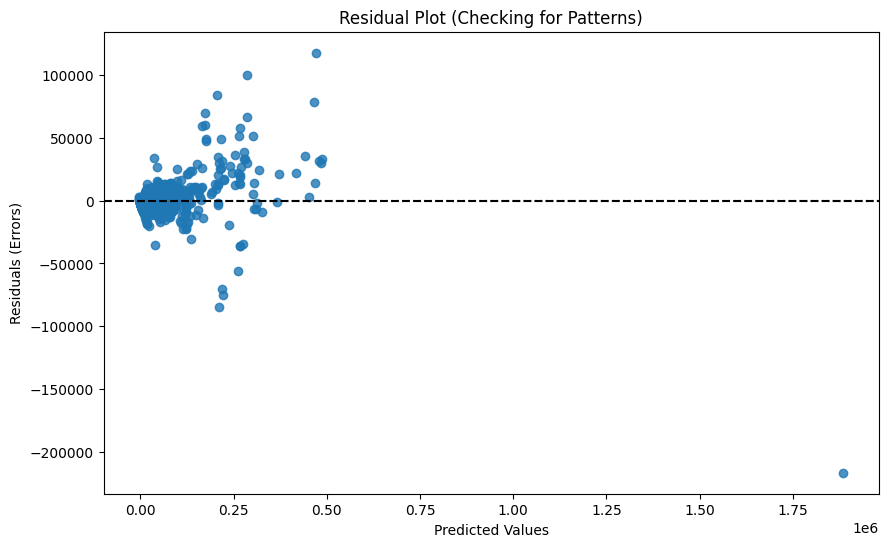

In [141]:
# Residual Plot
# Calculate residuals
residuals = y_test - y_pred

# One-line residual plot with Seaborn
plt.figure(figsize=(10, 6))
sns.residplot(x=y_pred, y=residuals, line_kws={'color': 'red'})

plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Errors)')
plt.title('Residual Plot (Checking for Patterns)')
plt.axhline(y=0, color='black', linestyle='--')
plt.show()

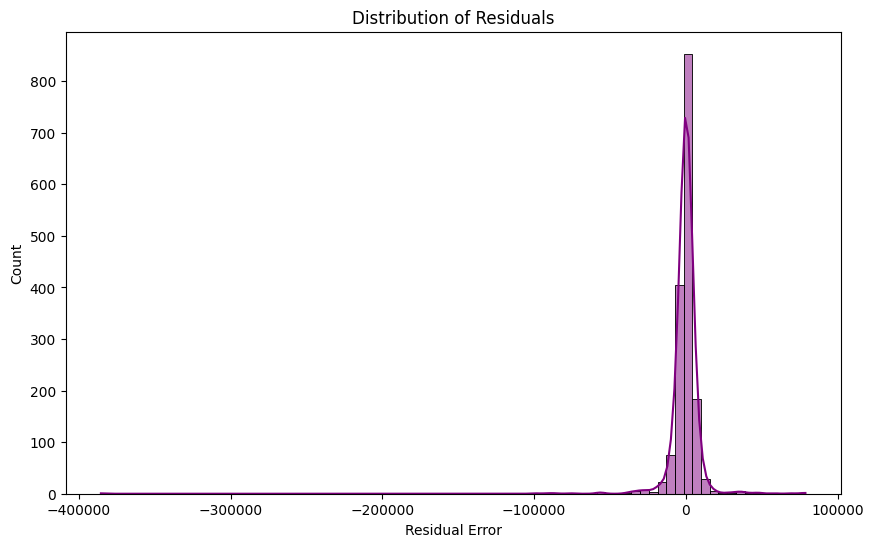

In [142]:
# Distribution of errors should be bell shaped
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Distribution of Residuals')
plt.xlabel('Residual Error')
plt.show()